In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/raw/accepted_2007_to_2018Q4.csv')

C:\Users\souradip\AppData\Local\Temp\ipykernel_6676\4204763957.py:1: DtypeWarning: Columns (0,19,49,59,118,129,130,131,134,135,136,139,145,146,147) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/raw/accepted_2007_to_2018Q4.csv')


In [3]:
df.shape

(2260701, 151)

In [4]:
df.columns.to_list()

['id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'last_fico_range_high',
 'last_fico_range_low',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'annual_inc_joint',
 '

- Too many columns inthe dataset we need to select featurs that are relavent to our problem

In [5]:
model_features = [
    # Borrower info
    'annual_inc', 'verification_status', 'emp_length', 'home_ownership', 'addr_state',
    'dti', 'purpose', 'application_type',

    # Credit risk indicators
    'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq',
    'mths_since_last_record', 'open_acc', 'total_acc', 'pub_rec', 'revol_bal',
    'revol_util', 'collections_12_mths_ex_med', 'mths_since_last_major_derog',
    'delinq_2yrs', 'acc_now_delinq', 'num_tl_90g_dpd_24m',

    # Loan application terms
    'loan_amnt', 'int_rate', 'term', 'installment', 'grade', 'sub_grade',
    'funded_amnt',

    # status
    'loan_status'
]

In [6]:
model_df = df[model_features].copy()

In [7]:
model_df.shape

(2260701, 31)

In [8]:
model_df['loan_status'].value_counts()

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

- There are lots too many classes in the "loan_status" like Late, Does not meet the credit policy. Status:Fully Paid etc we don't want to train our model with this so we will use Fully Paid & Charged Off status

In [9]:
keep_status = ['Fully Paid','Charged Off','Does not meet the credit policy. Status:Fully Paid',
               'Does not meet the credit policy. Status:Charged Off','Default']

model_df = model_df[model_df['loan_status'].isin(keep_status)]

default_status = ['Charged Off','Does not meet the credit policy. Status:Charged Off','Default']

model_df['loan_status'] = df['loan_status'].apply(lambda x: 1 if x in default_status else 0)

In [10]:
model_df['loan_status'].value_counts()

loan_status
0    1078739
1     269360
Name: count, dtype: int64

## EDA

In [11]:
model_df.head()

,annual_inc,verification_status,emp_length,home_ownership,addr_state,dti,purpose,application_type,fico_range_low,fico_range_high,...,acc_now_delinq,num_tl_90g_dpd_24m,loan_amnt,int_rate,term,installment,grade,sub_grade,funded_amnt,loan_status
0,55000.0,Not Verified,10+ years,MORTGAGE,PA,5.91,debt_consolidation,Individual,675.0,679.0,...,0.0,0.0,3600.0,13.99,36 months,123.03,C,C4,3600.0,0
1,65000.0,Not Verified,10+ years,MORTGAGE,SD,16.06,small_business,Individual,715.0,719.0,...,0.0,0.0,24700.0,11.99,36 months,820.28,C,C1,24700.0,0
2,63000.0,Not Verified,10+ years,MORTGAGE,IL,10.78,home_improvement,Joint App,695.0,699.0,...,0.0,0.0,20000.0,10.78,60 months,432.66,B,B4,20000.0,0
4,104433.0,Source Verified,3 years,MORTGAGE,PA,25.37,major_purchase,Individual,695.0,699.0,...,0.0,0.0,10400.0,22.45,60 months,289.91,F,F1,10400.0,0
5,34000.0,Source Verified,4 years,RENT,GA,10.20,debt_consolidation,Individual,690.0,694.0,...,0.0,0.0,11950.0,13.44,36 months,405.18,C,C3,11950.0,0


In [12]:
model_df['verification_status'].value_counts()

verification_status
Source Verified    521579
Verified           418979
Not Verified       407541
Name: count, dtype: int64

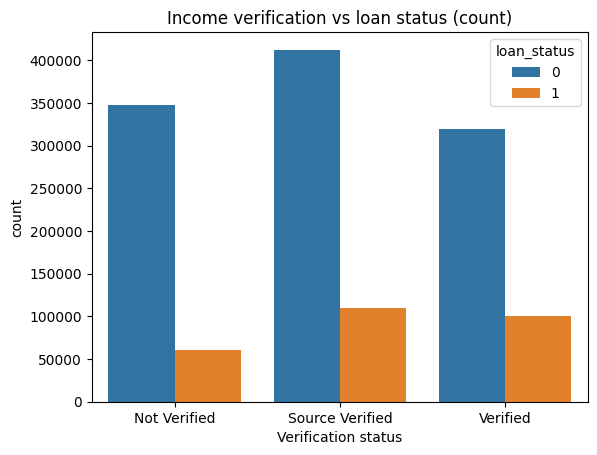

In [13]:
sns.countplot(model_df, x = 'verification_status', hue = 'loan_status')
plt.title('Income verification vs loan status (count)')
plt.xlabel('Verification status')
plt.show()

In [14]:
model_df.groupby('verification_status')['loan_status'].mean()

verification_status
Not Verified       0.147357
Source Verified    0.209614
Verified           0.238618
Name: loan_status, dtype: float64

- verified borrowers & Source Verified borrowers have higher default rate
- If you verify income more often for risky applicants, the group called “Verified” will naturally include more high-risk borrowers.

In [15]:
model_df.groupby('verification_status')[['annual_inc','dti','fico_range_low']].mean()

,annual_inc,dti,fico_range_low
verification_status,,,
Not Verified,69802.871223,17.657204,703.568819
Source Verified,80570.548203,17.507934,693.011078
Verified,77103.057327,19.827967,692.880658


- Verified group has lower FICO and high DTI percent on average.
- The income verification process is not random, it’s targeted toward higher-risk applicants.

In [16]:
model_df['home_ownership'].value_counts()

home_ownership
MORTGAGE    666852
RENT        535699
OWN         145027
ANY            286
OTHER          182
NONE            53
Name: count, dtype: int64

We can ignore Any, Other and None home ownership titles or just group them into one.

In [17]:
df['home_ownership_clean'] = df['home_ownership'].replace({'ANY': 'OTHER', 'NONE': 'OTHER', 'OTHER': 'OTHER'})

In [18]:
home_ownership = model_df.groupby('home_ownership')['loan_status'].mean().sort_values(ascending=False)
home_ownership

home_ownership
RENT        0.232296
OTHER       0.208791
OWN         0.206313
ANY         0.195804
MORTGAGE    0.172296
NONE        0.150943
Name: loan_status, dtype: float64

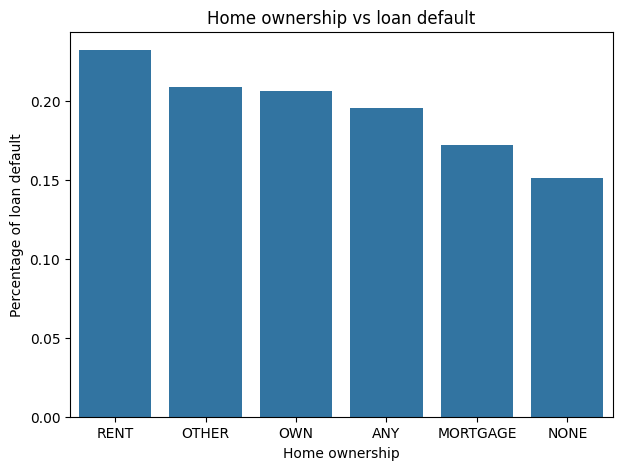

In [19]:
plt.figure(figsize=(7,5))
sns.barplot(home_ownership)
plt.xlabel('Home ownership')
plt.ylabel('Percentage of loan default')
plt.title('Home ownership vs loan default')
plt.show()

- Mortgage holdes default less, maybe because of stable income

In [24]:
model_df.groupby('home_ownership')[['fico_range_low','annual_inc','dti']].mean().sort_values(by='dti', ascending = False)

,fico_range_low,annual_inc,dti
home_ownership,,,
NONE,698.207547,62986.755102,19.089245
ANY,702.622378,79109.977168,18.709406
OWN,698.081599,71243.360682,18.705497
MORTGAGE,699.290135,86245.277710,18.367796
RENT,691.743628,65135.138471,18.042108
OTHER,700.989011,66667.021978,14.351538


In [26]:
model_df['purpose'].value_counts()

purpose
debt_consolidation    781442
credit_card           295625
home_improvement       87721
other                  78301
major_purchase         29550
medical                15614
small_business         15577
car                    14652
moving                  9526
vacation                9084
house                   7298
wedding                 2350
renewable_energy         936
educational              423
Name: count, dtype: int64

- no of lones for debt consolidation is higher followed by credit card

In [28]:
model_df.groupby('purpose')[['loan_status']].mean().sort_values(by='loan_status', ascending = False)

,loan_status
purpose,
small_business,0.298645
renewable_energy,0.237179
moving,0.233991
house,0.219101
medical,0.218458
debt_consolidation,0.211567
other,0.210827
educational,0.208038
vacation,0.191986


- Small Business Loans = High Risk
- Debt Consolidation = High Volume, Moderate Risk.
- Some Rare Purposes = High Default E.g., renewable_energy, moving, house
Weddings, Cars, Credit Cards = Safer

In [30]:
model_df['application_type'].value_counts(normalize = True)

application_type
Individual    0.980857
Joint App     0.019143
Name: proportion, dtype: float64

- 98% loans are taken by Individual

In [31]:
model_df.groupby('application_type')[['fico_range_low','annual_inc','dti','loan_status']].mean()

,fico_range_low,annual_inc,dti,loan_status
application_type,,,,
Individual,696.003458,76599.149575,18.007557,0.198904
Joint App,704.297838,57719.431705,32.140656,0.246067


- Joint application has a higher default rate & dti, despite having high fico score

In [34]:
state_default = model_df.groupby('addr_state')[['fico_range_low','annual_inc','dti','loan_status']].mean().sort_values(by='loan_status',ascending=False)
state_default

,fico_range_low,annual_inc,dti,loan_status
addr_state,,,,
MS,693.685368,69492.554318,20.527167,0.261107
NE,694.521158,64332.941462,20.135636,0.252227
AR,696.815742,66647.977197,20.161217,0.241105
AL,695.613397,68891.487599,20.134583,0.236347
OK,696.791348,70681.314141,19.881872,0.234672
LA,697.787297,74654.641055,19.342028,0.231770
NY,696.914039,79400.363879,16.548242,0.220506
NV,693.722408,71918.793820,18.523050,0.219698
FL,694.691370,71374.525751,18.475215,0.215018


C:\Users\souradip\AppData\Local\Temp\ipykernel_6676\138066668.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_default.index, y=state_default['loan_status'], palette='Reds_r')


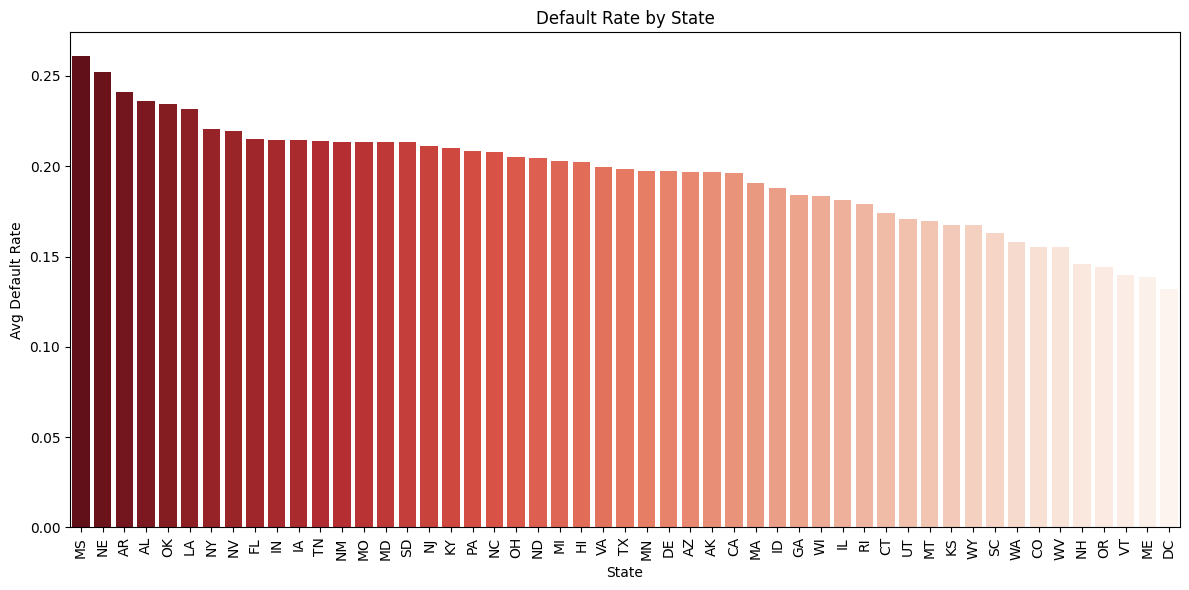

In [39]:
plt.figure(figsize=(12,6))
sns.barplot(x=state_default.index, y=state_default['loan_status'], palette='Reds_r')
plt.xticks(rotation=90)
plt.title('Default Rate by State')
plt.ylabel('Avg Default Rate')
plt.xlabel('State')
plt.tight_layout()
plt.show()

- Highest default: Mississippi (MS) at 26.1%, with high DTI and low income.
- High-risk range (23–25%): NE, AR, AL, OK, LA — all with high DTI and modest income.
- Lowest default: District of Columbia (DC) at 13.2%, highest income, lowest DTI.
- Low-risk range (13.8–15.8%): ME, VT, IA, NH, OR, WA — low DTI, strong credit or income.


In [ ]:
model_df.columns

Index(['annual_inc', 'verification_status', 'emp_length', 'home_ownership',
       'addr_state', 'dti', 'purpose', 'application_type', 'fico_range_low',
       'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq',
       'mths_since_last_record', 'open_acc', 'total_acc', 'pub_rec',
       'revol_bal', 'revol_util', 'collections_12_mths_ex_med',
       'mths_since_last_major_derog', 'delinq_2yrs', 'acc_now_delinq',
       'num_tl_90g_dpd_24m', 'loan_amnt', 'int_rate', 'term', 'installment',
       'grade', 'sub_grade', 'funded_amnt', 'loan_status'],
      dtype='object')